In [29]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pickle as pkl
import torch 
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from gen_data import gen_swiss_roll, gen_elliptic_clusters
from tqdm import tqdm

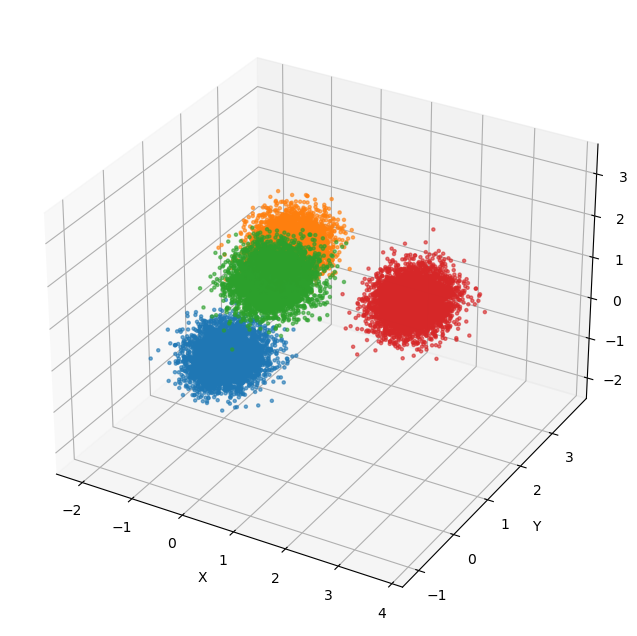

In [69]:
n = 5000
features = 3
n_clusters = 4
noise = 0.3
corr = 0.5
rad = 3
X = gen_elliptic_clusters(n, n_clusters, features, rad, corr, noise)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a color map based on the time variable
for i, X_cluster in enumerate(X):
    # Plot the trajectory in 3D space, colored by the time step
    sc = ax.scatter(X_cluster[:, 0], X_cluster[:, 1], X_cluster[:, 2], s=5, alpha=0.6)

# Set labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

In [59]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, X):
        a1 = torch.sigmoid(self.layer1(X))
        a2 = torch.sigmoid(self.layer2(a1))
        y_hat = self.layer3(a2)
        return y_hat

def evaluate_model(neural_net, X_test, y_test, verbose=False):
    """Given a neural network model, initial conditions, and a number of time steps, 
    simulate the Lorenz system and return the predicted and true states."""

    # Initialize arrays to hold the predicted and true states
    predicted_states = neural_net(torch.from_numpy(X_test).float())
    y_test_torch = torch.from_numpy(y_test)
    criterion = nn.CrossEntropyLoss()
    loss = criterion(predicted_states, y_test_torch)
    
    predicted_states = predicted_states.detach().numpy()
    accuracy = (predicted_states.argmax(axis=1) == y_test).mean()
    F1 = f1_score(y_test, predicted_states.argmax(axis=1), average='macro')
    if verbose:
        print(f'Loss: {loss.item()}')
        print(f'Accuracy: {accuracy}')
        print(f'F1: {F1}')
        print('-'*30)

    return predicted_states, loss.item(), accuracy, F1

In [107]:
X_train = X.reshape(-1, features)
y_train = np.repeat(np.arange(n_clusters), n)

X_tmp, X_test, y_tmp, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Inputs are current states, outputs are next states

X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.1, random_state=42)

X_train_torch = torch.from_numpy(X_train).float()
y_train_torch = torch.from_numpy(y_train)

# Create and train the neural network
nn_torch = NeuralNetwork(input_dim=features, hidden_dim=50, output_dim=n_clusters)

# Use Mean Squared Error Loss
criterion = nn.CrossEntropyLoss()

# Use Stochastic Gradient Descent Optimizer
optimizer = torch.optim.SGD(nn_torch.parameters(), lr=0.01)

store_loss = []
store_val_loss = []
store_f1 = []
store_accuracy = []

layer1_weights_store = []
layer_2_weights_store = []
layer_3_weights_store = []
# Training loop
for epoch in tqdm(range(5000)):
    # Forward pass: compute predicted y
    y_pred_torch = nn_torch(X_train_torch)
    # Compute loss
    loss = criterion(y_pred_torch, y_train_torch)
    store_loss.append(loss.item())
    # Print loss every 100 epochs



    # Zero gradients, backward pass, update weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        _, loss_val, acc, F1 = evaluate_model(nn_torch, X_val, y_val)
        store_val_loss.append(loss_val)
        store_f1.append(F1)
        store_accuracy.append(acc)
        # Extract specific weights and bias
        layer1_weights = nn_torch.state_dict()['layer1.weight']

        layer2_weights = nn_torch.state_dict()['layer2.weight']

        layer3_weights = nn_torch.state_dict()['layer3.weight']

        layer1_weights_store.append(layer1_weights)
        layer_2_weights_store.append(layer2_weights)
        layer_3_weights_store.append(layer3_weights)


100%|██████████| 5000/5000 [00:56<00:00, 88.31it/s] 


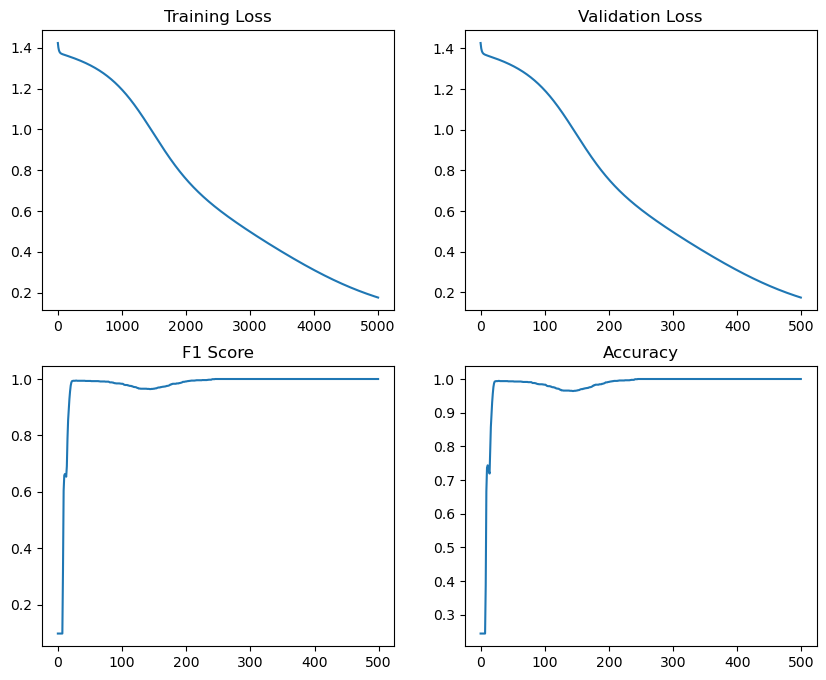

In [108]:
fig, ax = plt.subplots(2,2, figsize=(10, 8))
ax[0,0].plot(store_loss)
ax[0,0].set_title('Training Loss')
ax[0,1].plot(store_val_loss)
ax[0,1].set_title('Validation Loss')
ax[1,0].plot(store_f1)
ax[1,0].set_title('F1 Score')
ax[1,1].plot(store_accuracy)
ax[1,1].set_title('Accuracy')
plt.show()

In [109]:
for indx in range(len(layer1_weights_store)):
    layer1_weights = layer1_weights_store[indx]
    layer2_weights = layer_2_weights_store[indx]
    layer3_weights = layer_3_weights_store[indx]

    layer_1_eig = np.linalg.eigvalsh(layer1_weights.numpy().T @ layer1_weights.numpy())

    layer_2_eig = np.linalg.eigvalsh(layer2_weights.numpy().T @ layer2_weights.numpy())
    layer_3_eig = np.linalg.eigvalsh(layer3_weights.numpy().T @ layer3_weights.numpy())
    print('-'*30)
    print(layer_1_eig)
    print(layer_2_eig)
    print(layer_3_eig)
    #fig, ax = plt.subplots(1,3, figsize=(10, 8))
    #ax[0].hist(layer_1_eig, bins=10)
    #ax[0].set_title('Layer 1 Eigenvalues')
    #ax[1].hist(layer_2_eig, bins=10)
    #ax[1].set_title('Layer 2 Eigenvalues')
    #ax[2].hist(layer_3_eig, bins=10)
    #ax[2].set_title('Layer 3 Eigenvalues')
    #fig.show()

------------------------------
[ 9.326998 10.476858 15.899447]
[2.21756509e-05 2.05348944e-03 2.33046594e-03 3.72856390e-03
 7.57360039e-03 1.77867748e-02 1.98017769e-02 2.34648678e-02
 2.64540892e-02 3.58892865e-02 4.39593159e-02 5.01742922e-02
 5.94712347e-02 6.99981824e-02 7.30740651e-02 8.66935775e-02
 1.00583628e-01 1.24827914e-01 1.30172059e-01 1.42089292e-01
 1.58918038e-01 1.74673751e-01 1.80674225e-01 1.99510336e-01
 2.20105052e-01 2.31914997e-01 2.61949956e-01 2.76855588e-01
 3.00141990e-01 3.31420690e-01 3.62621367e-01 3.81044984e-01
 4.02070433e-01 4.31618959e-01 4.75457579e-01 5.13428748e-01
 5.89754283e-01 6.46537542e-01 6.58031940e-01 6.89585686e-01
 7.03903019e-01 7.63147116e-01 8.36483300e-01 8.85668397e-01
 9.52942789e-01 1.00207436e+00 1.17500687e+00 6.11609983e+00
 6.95269251e+00 1.49021606e+01]
[-2.49129073e-07 -2.16047638e-07 -1.52609857e-07 -1.50932138e-07
 -1.29121929e-07 -1.17090600e-07 -1.09518908e-07 -9.79308439e-08
 -9.50421395e-08 -8.39031031e-08 -6.8059769

In [94]:
# Test the evaluation function with random initial conditions
y_Tr, loss, acc, F1 = evaluate_model(nn_torch, X_train, y_train)
print('-'*30)
print(f"Loss: {loss}")
print(f"Accuracy: {acc}")
print(f"F1: {F1}")
y_Va, loss, acc, F1 = evaluate_model(nn_torch, X_val, y_val)
print('-'*30)
print(f"Loss: {loss}")
print(f"Accuracy: {acc}")
print(f"F1: {F1}")
y_Te, loss, acc, F1 = evaluate_model(nn_torch, X_test, y_test)
print('-'*30)
print(f"Loss: {loss}")
print(f"Accuracy: {acc}")
print(f"F1: {F1}")


------------------------------
Loss: 1.329727053642273
Accuracy: 0.7509027777777778
F1: 0.6675280718661689
------------------------------
Loss: 1.3299423456192017
Accuracy: 0.74375
F1: 0.6635224926249462
------------------------------
Loss: 1.3300483226776123
Accuracy: 0.749
F1: 0.6651453684922245


In [96]:
# Extract specific weights and bias
layer1_weights = nn_torch.state_dict()['layer1.weight']
layer1_bias = nn_torch.state_dict()['layer1.bias']

layer2_weights = nn_torch.state_dict()['layer2.weight']
layer2_bias = nn_torch.state_dict()['layer2.bias']

layer3_weights = nn_torch.state_dict()['layer3.weight']
layer3_bias = nn_torch.state_dict()['layer3.bias']

# Print weights and bias
print("Layer 1 weights:", layer1_weights)
print("Layer 1 bias:", layer1_bias)

print("Layer 2 weights:", layer2_weights)
print("Layer 2 bias:", layer2_bias)

print("Layer 3 weights:", layer3_weights)
print("Layer 3 bias:", layer3_bias)

Layer 1 weights: tensor([[-0.4473,  0.4393,  0.5418],
        [-0.5759,  0.0276, -0.1039],
        [-0.1341,  0.1802, -0.4390],
        [ 0.2075,  0.4198, -0.2000],
        [-0.5578,  0.2338, -0.5687],
        [ 0.0590,  0.4804,  0.3010],
        [-0.4132, -0.5687,  0.1726],
        [ 0.5471, -0.2818, -0.2736],
        [-0.4166, -0.3127,  0.3530],
        [-0.3474, -0.2951,  0.2214],
        [-0.1069,  0.4287, -0.0903],
        [ 0.2856, -0.4791, -0.1075],
        [-0.5013,  0.4607, -0.1063],
        [-0.2820, -0.5418, -0.1454],
        [-0.3173, -0.4869,  0.0403],
        [ 0.1020,  0.3078,  0.2919],
        [-0.1872, -0.1146,  0.4392],
        [-0.2194, -0.3929,  0.0607],
        [ 0.1331, -0.3902,  0.2825],
        [-0.2462, -0.3615,  0.5485],
        [ 0.2486, -0.0086, -0.2639],
        [-0.3791, -0.0836, -0.4887],
        [-0.5700, -0.1526,  0.3989],
        [-0.3862, -0.2169,  0.5004],
        [ 0.5351,  0.1448,  0.0944],
        [-0.3616, -0.3766,  0.1581],
        [ 0.1926,  0.